# **Step 1: Preparing Google Collab Setup**

In [1]:
# Import the library to work with Google Drive in Colab
from google.colab import drive

# Mount Google Drive to the Colab environment so files from Drive can be accessed
# This will prompt you to authorize access; once done, your Drive files will be available under '/content/drive'
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 2 : Importing Libraries**

In [6]:
# Importing NumPy for numerical operations, especially for handling arrays and matrices
import numpy as np

# Importing Matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt

# Importing RandomForestClassifier for building a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Importing Support Vector Classifier (SVC) for Support Vector Machine modeling
from sklearn.svm import SVC

# Importing metrics to evaluate model performance (confusion matrix, classification report, F1 score)
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Importing PCA for dimensionality reduction and feature extraction
from sklearn.decomposition import PCA

# Importing SMOTE for handling imbalanced datasets by oversampling minority classes
from imblearn.over_sampling import SMOTE

# Importing XGBClassifier for Extreme Gradient Boosting (XGBoost), a high-performance ML algorithm
from xgboost import XGBClassifier

# Importing Seaborn for more advanced and visually appealing data visualizations
import seaborn as sns

# **Step 3: Loading EEG Data**

In [7]:
# Loading the training feature data (EEG signals) from a NumPy file
x_train = np.load('/content/drive/MyDrive/Npy_files/x_train.npy', allow_pickle=True)

# Loading the testing feature data from a NumPy file
x_test = np.load('/content/drive/MyDrive/Npy_files/x_test.npy', allow_pickle=True)

# Loading the corresponding training labels (seizure classes)
y_train = np.load('/content/drive/MyDrive/Npy_files/y_train.npy', allow_pickle=True)

# Loading the corresponding testing labels
y_test = np.load('/content/drive/MyDrive/Npy_files/y_test.npy', allow_pickle=True)

In [8]:
# Displaying the shape of the training data and labels
# This helps confirm the number of samples and the dimensions of each sample
print(x_train.shape, y_train.shape)

(7011, 19, 500) (7011,)


# **Step 4: Visualizing Given Dataset**

## **4.1 Label Distribution**

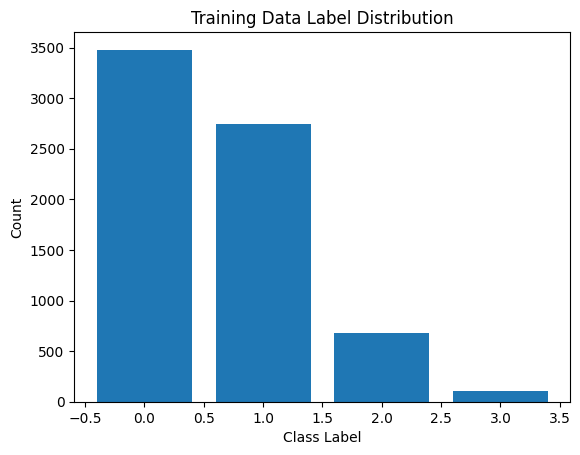

In [9]:
# Count the number of samples in each class of the training labels
labels, counts = np.unique(y_train, return_counts=True)

plt.bar(labels, counts)
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Training Data Label Distribution")
plt.show()

## **4.2 Sample EEG Plot**

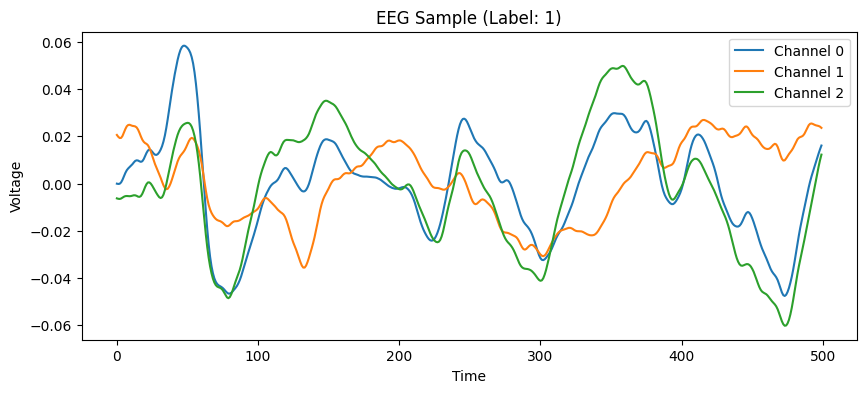

In [10]:
# Select the first EEG sample from the training data
sample = x_train[0]

plt.figure(figsize=(10, 4))


# Plot the signal from the first 3 channels of this sample
for i in range(3):  # Loop through channels 0, 1, and 2
    plt.plot(sample[i], label=f'Channel {i}')  # Plot the voltage over time for each channel

plt.title(f"EEG Sample (Label: {y_train[0]})")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()

# **Step 5: Flatten Data for ML Models**

In [11]:
# Reshape the 3D EEG training data into 2D format for machine learning models
# Original shape: (num_samples, num_channels, time_points)
# New shape: (num_samples, num_channels * time_points)
x_train_flat = x_train.reshape(x_train.shape[0], -1)

# Do the same reshaping for the test data
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# **Step 6: Train 3 Models (Without Feature Engineering)**

## **6.1 Random Forest**

In [12]:
# Initialize a Random Forest classifier with a fixed random seed for reproducibility
rf = RandomForestClassifier(random_state=42)

# Train the Random Forest model on the flattened training data
rf.fit(x_train_flat, y_train)

# Predict the class labels for the test data using the trained model
y_pred_rf = rf.predict(x_test_flat)

# Print a detailed classification report (precision, recall, f1-score, etc.) for the Random Forest predictions
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Random Forest:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91       416
           1       0.90      0.87      0.88       289
           2       0.91      0.74      0.81        68
           3       1.00      0.17      0.29         6

    accuracy                           0.89       779
   macro avg       0.92      0.68      0.72       779
weighted avg       0.89      0.89      0.89       779



## **6.2 SVM**

In [13]:
# Initialize a Support Vector Machine (SVM) classifier with default parameters
svm = SVC()

# Train the SVM model on the flattened training data
svm.fit(x_train_flat, y_train)

# Predict the class labels for the test data using the trained SVM model
y_pred_svm = svm.predict(x_test_flat)

# Print a detailed classification report (precision, recall, f1-score, etc.) for the SVM predictions
print("SVM:\n", classification_report(y_test, y_pred_svm))

SVM:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81       416
           1       0.87      0.66      0.75       289
           2       1.00      0.15      0.26        68
           3       0.00      0.00      0.00         6

    accuracy                           0.76       779
   macro avg       0.65      0.44      0.46       779
weighted avg       0.79      0.76      0.74       779



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **6.3 XGBoost**

In [14]:
# Importing XGBoost Classifier
xgb = XGBClassifier(random_state=42)

# Training the XGBoost model using the flattened training data
xgb.fit(x_train_flat, y_train)

# Predicting the labels of the test set using the trained model
y_pred_xgb = xgb.predict(x_test_flat)

# Printing classification report for the XGBoost model performance
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

XGBoost:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       416
           1       0.98      0.85      0.91       289
           2       0.92      0.84      0.88        68
           3       1.00      0.67      0.80         6

    accuracy                           0.92       779
   macro avg       0.94      0.83      0.88       779
weighted avg       0.92      0.92      0.92       779



# **Step 7: Feature Engineering + Balancing**

## **7.1 Apply PCA**

In [15]:
# Importing PCA (Principal Component Analysis) for dimensionality reduction
pca = PCA(n_components=100, random_state=42)

# Applying PCA to the flattened training data, reducing the features to 100 components
x_train_pca = pca.fit_transform(x_train_flat)

# Applying the same PCA transformation to the flattened test data
x_test_pca = pca.transform(x_test_flat)

## **7.2 Balance the Data**

In [16]:
# Importing SMOTE (Synthetic Minority Over-sampling Technique) to handle class imbalance
sm = SMOTE(random_state=42)

# Applying SMOTE to the PCA-transformed training data to balance the classes
# This generates synthetic samples for the underrepresented classes
x_train_bal, y_train_bal = sm.fit_resample(x_train_pca, y_train)

# **Step 8: Retrain Models on Balanced + Engineered Data**

## **8.1 Random Forest**

RF after engineering:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       416
           1       0.80      0.82      0.81       289
           2       0.66      0.54      0.60        68
           3       0.33      0.17      0.22         6

    accuracy                           0.81       779
   macro avg       0.66      0.60      0.62       779
weighted avg       0.81      0.81      0.81       779



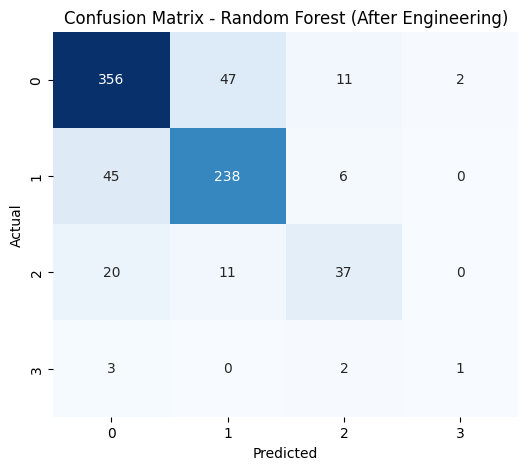

In [28]:
# Train a new Random Forest model on the balanced and PCA-reduced training data
rf2 = RandomForestClassifier()
rf2.fit(x_train_bal, y_train_bal)

# Predict on the PCA-transformed original test set
y_pred_rf2 = rf2.predict(x_test_pca)

# Print the classification report to evaluate performance after feature engineering and balancing
print("RF after engineering:\n", classification_report(y_test, y_pred_rf2))


# Define a function to plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Create a heatmap from the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")  # Label for x-axis
    plt.ylabel("Actual")     # Label for y-axis
    plt.title(f"Confusion Matrix - {title}")  # Title of the plot
    plt.show()

# Plot the confusion matrix for the original Random Forest model (before feature engineering)
plot_confusion_matrix(y_test, y_pred_rf2, "Random Forest (After Engineering)")

## **8.2 SVM**

SVM (after feature engineering):
              precision    recall  f1-score   support

           0       0.77      0.84      0.81       416
           1       0.90      0.65      0.76       289
           2       0.64      0.66      0.65        68
           3       0.04      0.33      0.08         6

    accuracy                           0.75       779
   macro avg       0.59      0.62      0.57       779
weighted avg       0.80      0.75      0.77       779



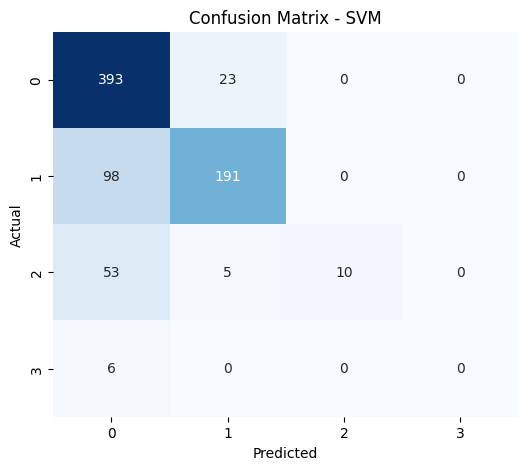

In [18]:
# Training an SVM model on the balanced and PCA-reduced training data
svm2 = SVC()
svm2.fit(x_train_bal, y_train_bal)

# Making predictions using the test data that was also PCA-transformed
y_pred_svm2 = svm2.predict(x_test_pca)

# Printing the classification report to evaluate model performance
print("SVM (after feature engineering):")
print(classification_report(y_test, y_pred_svm2))

# Plotting the confusion matrix for the original (non-engineered) SVM model
# You may want to change this to y_pred_svm2 if you mean to visualize the new model
plot_confusion_matrix(y_test, y_pred_svm, "SVM")

## **8.3 XGBoost**

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:59:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (after feature engineering):
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       416
           1       0.84      0.84      0.84       289
           2       0.66      0.78      0.72        68
           3       0.50      0.33      0.40         6

    accuracy                           0.84       779
   macro avg       0.72      0.70      0.71       779
weighted avg       0.85      0.84      0.84       779



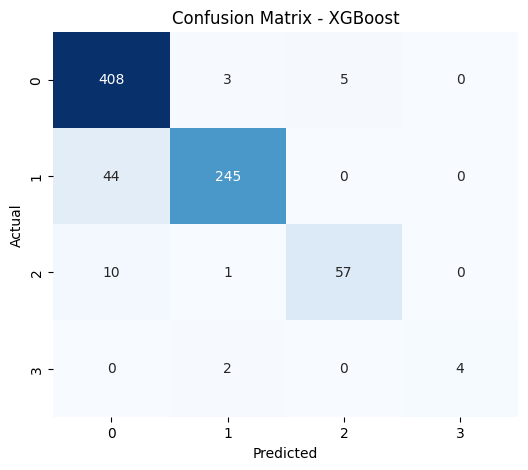

In [19]:
# Training XGBoost classifier after applying feature engineering and SMOTE balancing
xgb2 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')  # Avoid warning with label encoder; use multiclass log loss metric
xgb2.fit(x_train_bal, y_train_bal)  # Fit model on the PCA-transformed, SMOTE-balanced training data

# Predict on PCA-transformed test data
y_pred_xgb2 = xgb2.predict(x_test_pca)

# Display performance report
print("XGBoost (after feature engineering):")
print(classification_report(y_test, y_pred_xgb2))  # Shows precision, recall, f1-score for each class

# Plot confusion matrix to visualize true vs predicted labels for the original (pre-engineered) XGBoost model (optional)
plot_confusion_matrix(y_test, y_pred_xgb2, "XGBoost (After Engineering)")

## **9 Implementation of CNN**

## **9.1 Prepare Data For CNN Model**

In [22]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# ----------------------------
# Preprocessing for 1D CNN model
# ----------------------------

# Reshape input data for 1D CNN
# Original shape: (samples, channels, time_steps) → Required shape: (samples, time_steps, channels)
# This allows the 1D convolution to process over the time dimension for each EEG channel
x_train_cnn = np.transpose(x_train, (0, 2, 1))  # Transpose to shape: (7011, 500, 19)
x_test_cnn = np.transpose(x_test, (0, 2, 1))    # Transpose to shape: (779, 500, 19)

# One-hot encode the labels to use with categorical cross-entropy
# Converts class labels like [0, 1, 2, 3] to vectors like [1,0,0,0], [0,1,0,0], etc.
num_classes = len(np.unique(y_train))           # Find number of unique output classes
y_train_cat = to_categorical(y_train, num_classes)  # Convert training labels to one-hot
y_test_cat = to_categorical(y_test, num_classes)    # Convert test labels to one-hot

## **9.2 Define 1-D CNN Model**

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# Define the 1D CNN model architecture
model = Sequential([

    # First convolutional layer
    # Applies 64 filters of size 7 over the time dimension of each EEG channel
    Conv1D(filters=64, kernel_size=7, activation='relu', input_shape=(500, 19)),
    BatchNormalization(),             # Normalize activations to speed up training and improve stability
    MaxPooling1D(pool_size=2),        # Downsample the time dimension by a factor of 2

    # Second convolutional block with more filters and smaller kernel
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Flatten the output into a 1D vector for the dense layers
    Flatten(),

    # Fully connected layer with 64 neurons
    Dense(64, activation='relu'),
    Dropout(0.5),                     # Dropout to reduce overfitting

    # Output layer with softmax activation for multi-class classification
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **9.3 Compile and Train the Model:**

In [24]:
# Compile the CNN model
model.compile(
    optimizer='adam',                      # Adam optimizer adapts learning rate during training
    loss='categorical_crossentropy',       # Loss function for multi-class classification
    metrics=['accuracy']                   # Track accuracy as evaluation metric
)

# Train the model on the training data
history = model.fit(
    x_train_cnn, y_train_cat,              # Training inputs and one-hot encoded labels
    epochs=10,                             # Number of times the model sees the entire training data
    batch_size=64,                         # Number of samples processed before model update
    validation_data=(x_test_cnn, y_test_cat)  # Use test data for validation after each epoch
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 271ms/step - accuracy: 0.6563 - loss: 1.8426 - val_accuracy: 0.5494 - val_loss: 0.9349
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 29s 258ms/step - accuracy: 0.8292 - loss: 0.5092 - val_accuracy: 0.5443 - val_loss: 2.6552
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - accuracy: 0.8687 - loss: 0.3660 - val_accuracy: 0.5533 - val_loss: 4.3906
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.8955 - loss: 0.2816 - val_accuracy: 0.5777 - val_loss: 5.6635
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 254ms/step - accuracy: 0.8964 - loss: 0.2614 - val_accuracy: 0.6804 - val_loss: 3.4294
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 29s 261ms/step - accuracy: 0.8923 - loss: 0.2868 - val_accuracy: 0.8126 - val_loss: 1.6595
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 247ms/step - accuracy: 0.9165 - loss: 0.2186 - val_accuracy: 0.9037 - val_loss: 0.3325
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 246ms/step - accuracy: 0.9247 - loss: 0

## **9.4 Plot Training Results**

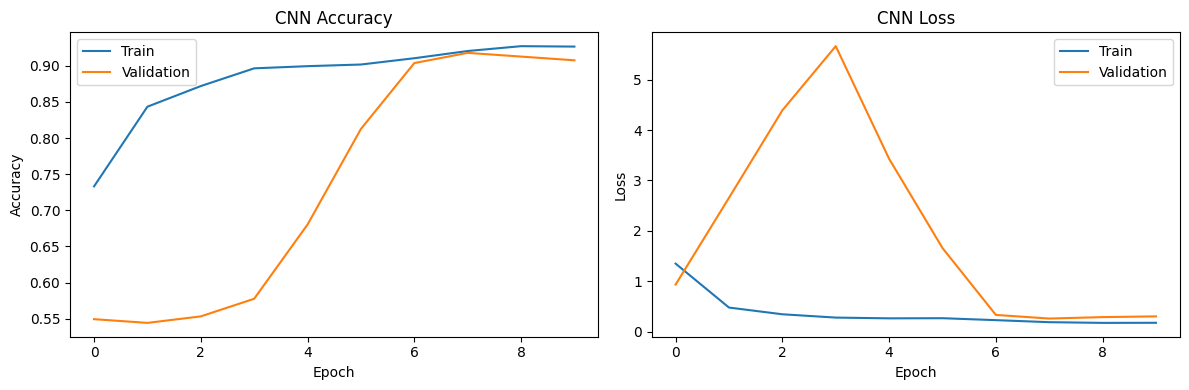

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))  # Set the figure size for side-by-side plots

# Plotting Accuracy
plt.subplot(1, 2, 1)  # Create subplot for accuracy (1 row, 2 columns, 1st subplot)
plt.plot(history.history['accuracy'], label='Train')         # Training accuracy
plt.plot(history.history['val_accuracy'], label='Validation') # Validation accuracy
plt.title('CNN Accuracy')  # Title of the plot
plt.xlabel('Epoch')        # X-axis label
plt.ylabel('Accuracy')     # Y-axis label
plt.legend()               # Display legend

# Plotting Loss
plt.subplot(1, 2, 2)  # Create subplot for loss (2nd subplot)
plt.plot(history.history['loss'], label='Train')          # Training loss
plt.plot(history.history['val_loss'], label='Validation') # Validation loss
plt.title('CNN Loss')  # Title of the plot
plt.xlabel('Epoch')    # X-axis label
plt.ylabel('Loss')     # Y-axis label
plt.legend()           # Display legend

plt.tight_layout()     # Adjust subplots to fit in figure area.
plt.show()             # Show the plots

## **9.5 Evaluate Model Performance**

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       416
           1       0.95      0.83      0.89       289
           2       0.92      0.88      0.90        68
           3       1.00      1.00      1.00         6

    accuracy                           0.91       779
   macro avg       0.94      0.92      0.93       779
weighted avg       0.91      0.91      0.91       779



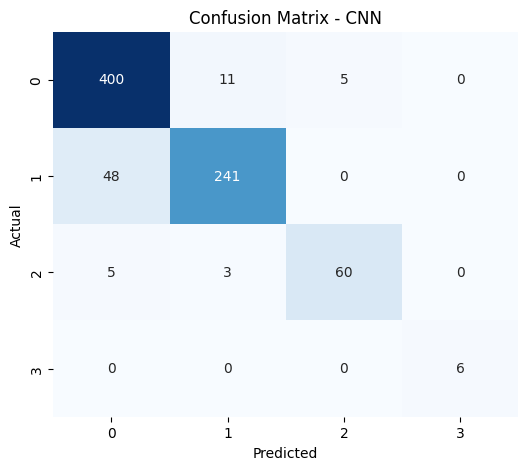

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict
y_pred_cnn = model.predict(x_test_cnn)             # Use the trained model to predict on the test set
y_pred_labels = np.argmax(y_pred_cnn, axis=1)      # Get the predicted class labels by finding the index of max value (softmax output)

# Report
print(classification_report(y_test, y_pred_labels))  # Print the classification report (precision, recall, f1-score)
plot_confusion_matrix(y_test, y_pred_labels, "CNN")  # Plot the confusion matrix for the CNN model's predictions

## **10. Comparison of different Machine Learning Approaches**

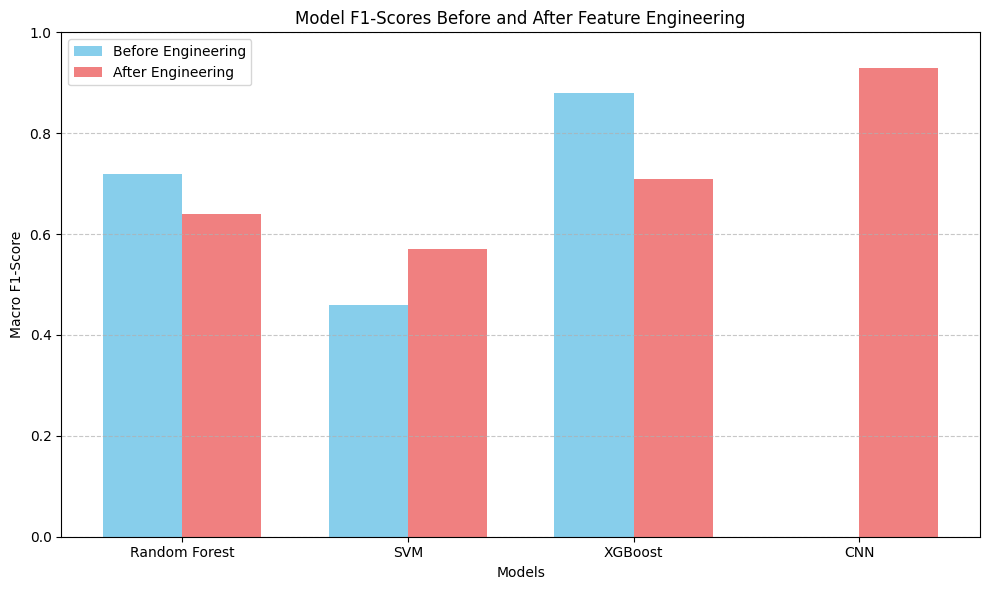

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and their F1 scores before and after feature engineering
models = ['Random Forest', 'SVM', 'XGBoost', 'CNN']  # List of models
f1_before = [0.72, 0.46, 0.88, 0]  # F1 scores before feature engineering (CNN not used before, set to 0 for plot)
f1_after = [0.64, 0.57, 0.71, 0.93]  # F1 scores after feature engineering

x = np.arange(len(models))  # Position for each model on the x-axis (e.g., [0, 1, 2, 3])
bar_width = 0.35  # Width of the bars for the grouped bar plot

# Plotting the bar chart
plt.figure(figsize=(10, 6))  # Set the figure size
plt.bar(x - bar_width/2, f1_before, width=bar_width, label='Before Engineering', color='skyblue')  # Plot bars for F1 before engineering
plt.bar(x + bar_width/2, f1_after, width=bar_width, label='After Engineering', color='lightcoral')  # Plot bars for F1 after engineering

# Adding labels and title
plt.xlabel('Models')  # Label for the x-axis
plt.ylabel('Macro F1-Score')  # Label for the y-axis
plt.title('Model F1-Scores Before and After Feature Engineering')  # Title of the plot
plt.xticks(x, models)  # Set the x-axis labels to the model names
plt.ylim(0, 1)  # Set the y-axis limits from 0 to 1 (since F1 scores range between 0 and 1)
plt.legend()  # Display the legend
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add a grid to the y-axis for better readability

# Save the figure (optional)
plt.tight_layout()  # Adjust layout for better spacing
plt.savefig("f1_comparison.png")  # Save the plot as an image file
plt.show()  # Display the plot